# Multi-class Prediction of Chronic Kidney Disease Stages

**Autori:** Marija Todorović IN 13/2022, Nenad Lukić IN 17/2022  
**Baza podataka:** [Kidney Disease Dataset – Kaggle](https://www.kaggle.com/datasets/amanik000/kidney-disease-dataset)

---

### Opis problema

Skup podataka sadrži medicinske i demografske podatke o pacijentima koji se koriste za procenu hronične bolesti bubrega. Problem je definisan kao višeklasna klasifikacija sa pet kategorija ciljne promenljive:

| Klasa | Opis | Udeo u skupu |
|---|---|---|
| No_Disease | Nema bolesti | ~80.0% |
| Low_Risk | Mali rizik | ~10.0% |
| Moderate_Risk | Srednji rizik | ~4.0% |
| High_Risk | Visoki rizik | ~4.0% |
| Severe_Disease | Ozbiljna bolest | ~2.0% |

**Napomena:** Skup podataka je izrazito neuravnotežen – dominantna klasa čini 80% uzoraka. Ovo će biti uzeto u obzir tokom modelovanja.

### Plan rada
1. Učitavanje i inicijalni pregled podataka
2. Eksplorativna analiza (EDA)
3. Priprema podataka (preprocessing)
4. Klasifikacija: kNN
5. Klasifikacija: Random Forest
6. Klasifikacija: SVM
7. Redukcija dimenzionalnosti (PCA, LDA) + ponovna klasifikacija
8. Poređenje rezultata i zaključak


---
# 1. Učitavanje biblioteka i podataka

In [1]:
# Standardne biblioteke
import numpy as np
import pandas as pd 

# Vizualizacija
import matplotlib.pyplot as plt
import seaborn as sb

# Scikit-learn
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.neighbors import KNeighborsClassifier 
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import make_scorer
from sklearn.metrics import f1_score

from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, accuracy_score
)

from sklearn.ensemble import RandomForestClassifier 
from sklearn.svm import SVC

In [2]:
# Učitavanje skupa podataka
df = pd.read_csv('kidney_disease_dataset.csv')
print(f'Dimenzije skupa: {df.shape}')
print(f'Broj uzoraka: {df.shape[0]}, Broj obeležja: {df.shape[1]}')
df.head()

Dimenzije skupa: (20538, 43)
Broj uzoraka: 20538, Broj obeležja: 43


,Age of the patient,Blood pressure (mm/Hg),Specific gravity of urine,Albumin in urine,Sugar in urine,Red blood cells in urine,Pus cells in urine,Pus cell clumps in urine,Bacteria in urine,Random blood glucose level (mg/dl),...,Smoking status,Body Mass Index (BMI),Physical activity level,Duration of diabetes mellitus (years),Duration of hypertension (years),Cystatin C level,Urinary sediment microscopy results,C-reactive protein (CRP) level,Interleukin-6 (IL-6) level,Target
0,54,167,1.023,1,4,normal,abnormal,not present,not present,96,...,yes,25.3,low,4,16,0.67,normal,4.88,10.23,No_Disease
1,42,127,1.023,3,2,normal,normal,not present,present,73,...,no,20.6,moderate,3,13,0.55,abnormal,4.49,13.11,Low_Risk
2,38,148,1.016,0,0,abnormal,normal,not present,not present,77,...,no,38.4,high,11,23,2.37,abnormal,4.57,13.27,No_Disease
3,7,98,1.017,4,0,abnormal,normal,not present,present,225,...,no,24.7,high,24,3,2.54,abnormal,8.57,12.36,No_Disease
4,67,174,1.015,1,1,normal,abnormal,not present,not present,376,...,yes,17.6,high,22,24,1.90,normal,6.75,1.46,No_Disease


---
## 2. Eksplorativna analiza podataka (EDA)

Cilj ove sekcije je da steknemo uvid u strukturu podataka: tipove obeležja, raspodelu vrednosti, neuravnoteženost klasa i međusobne korelacije numeričkih obeležja.

In [3]:
# Deskriptivna statistika numeričkih obeležja
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age of the patient,20538.0,47.477895,24.941947,5.000000,26.000000,47.000000,69.000000,90.000000
Blood pressure (mm/Hg),20538.0,130.352079,29.063838,80.000000,105.000000,131.000000,156.000000,180.000000
Specific gravity of urine,20538.0,1.015041,0.005793,1.005000,1.010000,1.015000,1.020000,1.025000
Albumin in urine,20538.0,2.501266,1.697084,0.000000,1.000000,3.000000,4.000000,5.000000
Sugar in urine,20538.0,2.494595,1.701059,0.000000,1.000000,2.000000,4.000000,5.000000
Random blood glucose level (mg/dl),20538.0,284.630295,124.633265,70.000000,176.000000,284.500000,393.000000,500.000000
Blood urea (mg/dl),20538.0,104.094240,55.726482,7.002370,55.864665,104.401355,152.480048,199.994361
Serum creatinine (mg/dl),20538.0,7.781865,4.179925,0.500000,4.200000,7.780000,11.430000,15.000000
Sodium level (mEq/L),20538.0,135.076646,8.651000,120.000613,127.563468,135.044974,142.607311,149.999914
Potassium level (mEq/L),20538.0,4.992314,0.871026,3.500005,4.229885,4.990991,5.749899,6.499827


Broj uzoraka po klasi:
                 Broj  Procenat (%)
Target                             
No_Disease      16432         80.01
Low_Risk         2054         10.00
Moderate_Risk     821          4.00
High_Risk         821          4.00
Severe_Disease    410          2.00


C:\Users\marij\AppData\Local\Temp\ipykernel_21816\2789017744.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.barplot(x=class_counts.index, y=class_counts.values, palette='Set2', ax=axes[0])


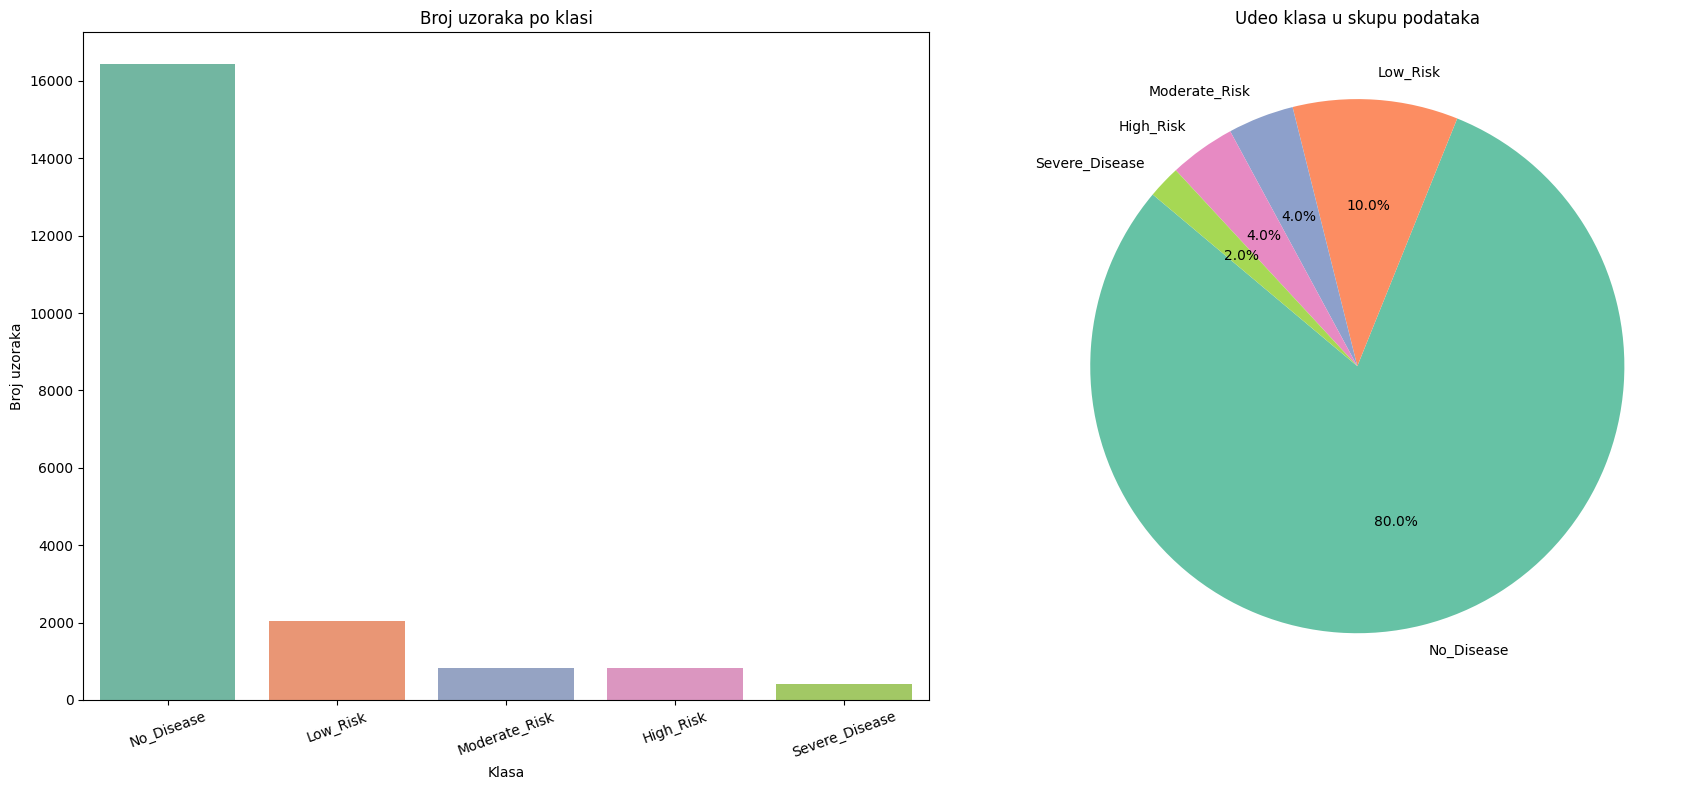

In [4]:
# Raspodela ciljne promenljive
target_col = 'Target'  

class_counts = df[target_col].value_counts()
class_pct = df[target_col].value_counts(normalize=True) * 100

print('Broj uzoraka po klasi:')
print(pd.DataFrame({'Broj': class_counts, 'Procenat (%)': class_pct.round(2)}))

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Barplot
sb.barplot(x=class_counts.index, y=class_counts.values, palette='Set2', ax=axes[0])
axes[0].set_title('Broj uzoraka po klasi')
axes[0].set_xlabel('Klasa')
axes[0].set_ylabel('Broj uzoraka')
axes[0].tick_params(axis='x', rotation=20)

# Pie chart
axes[1].pie(class_counts.values, labels=class_counts.index, autopct='%1.1f%%',
            startangle=140, colors=sb.color_palette('Set2', len(class_counts)))
axes[1].set_title('Udeo klasa u skupu podataka')

plt.tight_layout()
plt.savefig('Prilozi/01_raspodela_klasa.png', dpi=150, bbox_inches='tight')
plt.show()

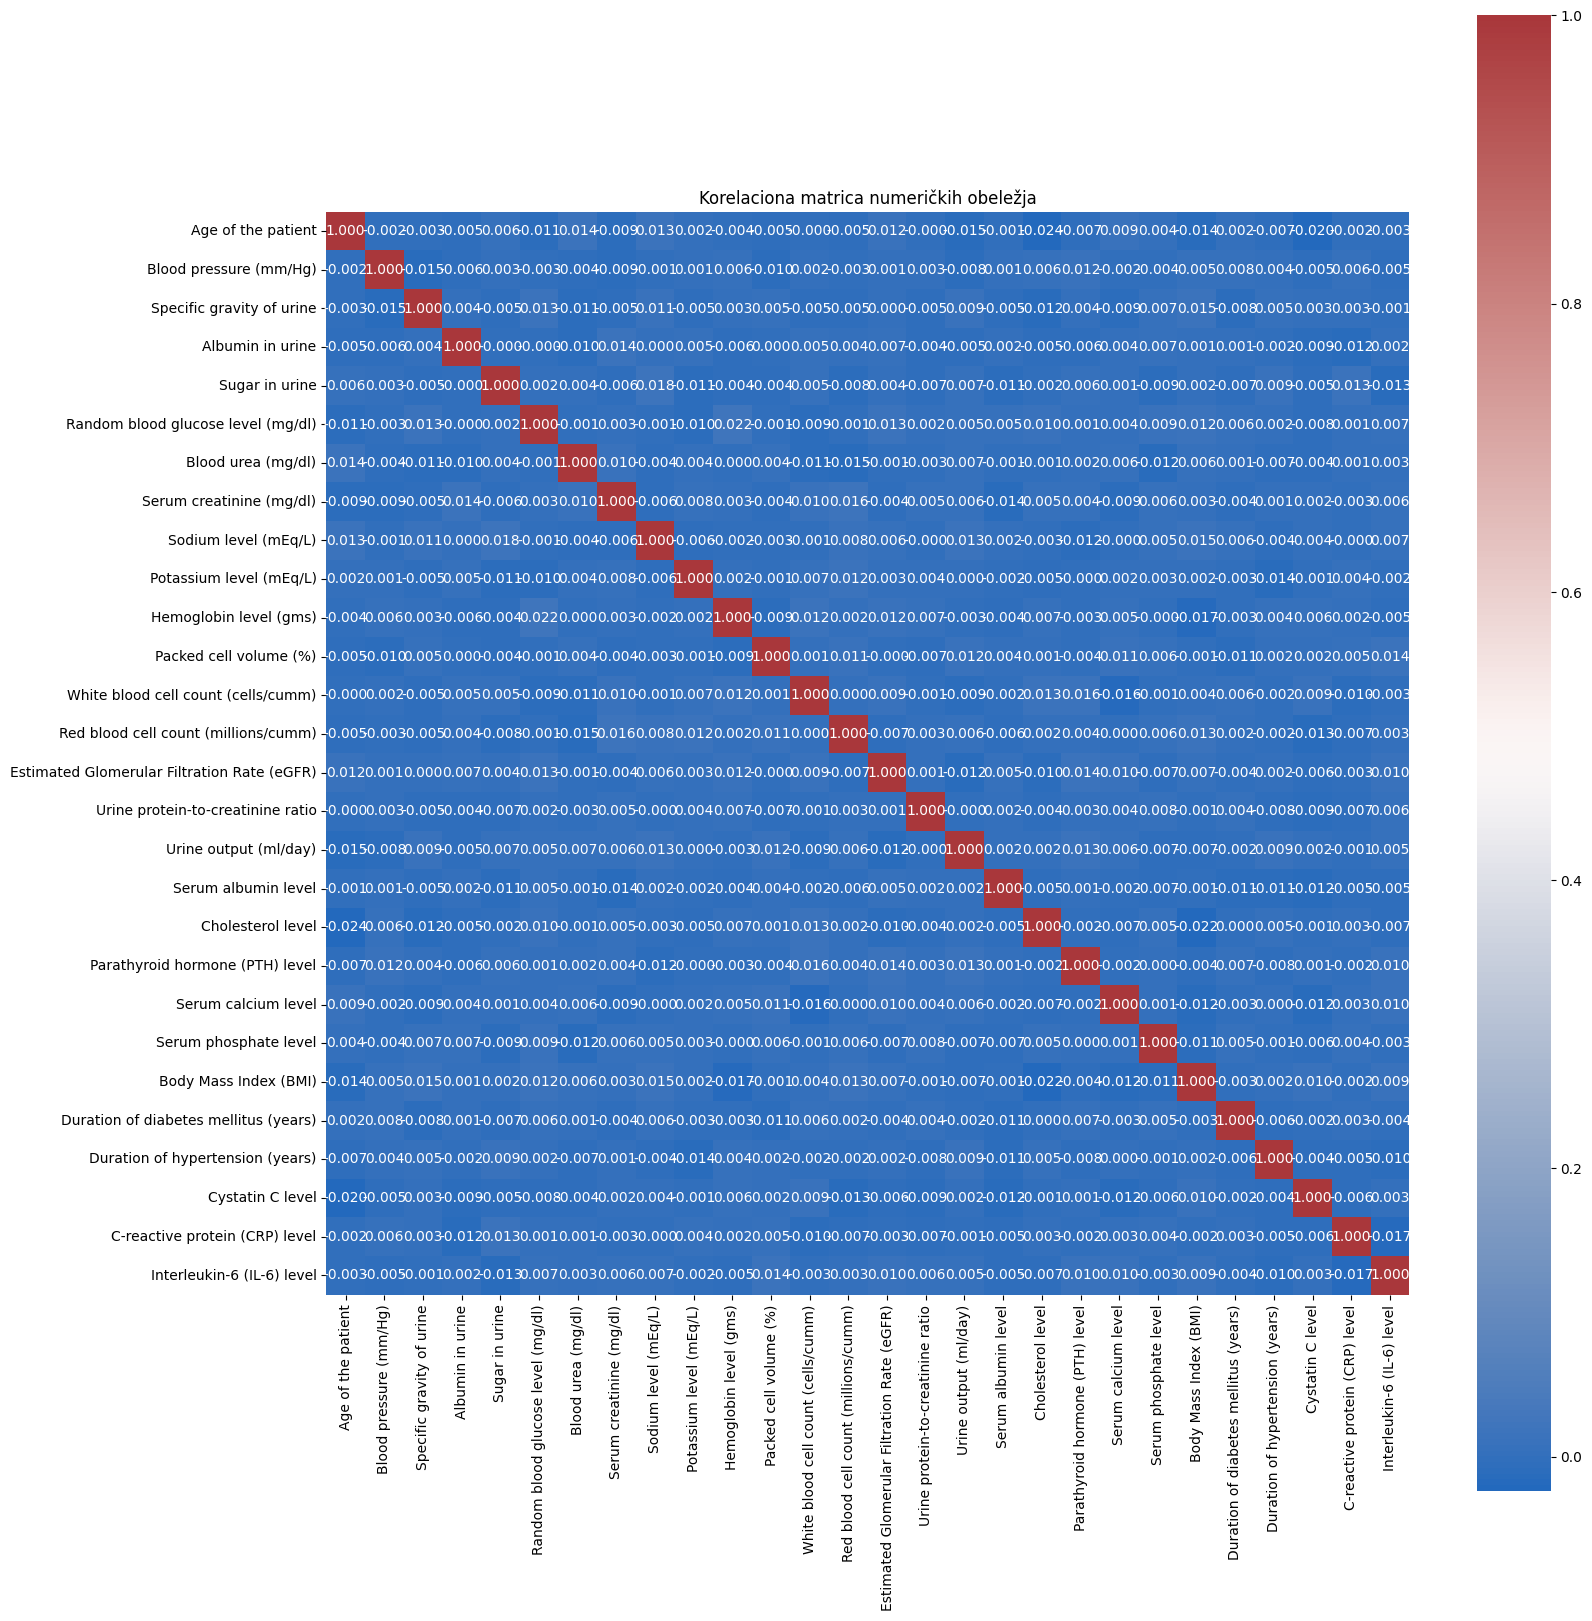

In [5]:
# Korelaciona matrica numeričkih obeležja 
numerical = df.select_dtypes(include=['int64', 'float64'])
corr = numerical.corr(method='pearson')

plt.figure(figsize=(17,17))
sb.heatmap(corr, annot=True, fmt=".3f", cmap="vlag", square=True)
plt.title("Korelaciona matrica numeričkih obeležja")
plt.tight_layout()
plt.savefig('Prilozi/02_korelaciona_matrica.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3. Priprema podataka (Preprocessing)

U ovoj sekciji:
- Definišemo cilj i obeležja
- Izbacujemo obeležja koja su identifikovana kao neinformativna (specifična gravitacija urina, albumin u urinu)
- Delimo skup na train (85%) i test (15%) deo, stratifikovano zbog neuravnoteženosti klasa
- Vršimo transformacije obeležja: 
    - Skaliramo numerička obeležja i 
    - Enkodujemo kategorička obeležja.
- Kreiramo petostruku podelu podataka za unakrsnu validaciju

In [6]:
# Definišemo cilj i obeležja
target_col = 'Target'

cat_cols = ['Sugar in urine', 'Albumin in urine',
            'Red blood cells in urine', 'Pus cells in urine', 
            'Pus cell clumps in urine', 
            'Bacteria in urine', 'Hypertension (yes/no)', 
            'Diabetes mellitus (yes/no)', 'Coronary artery disease (yes/no)', 
            'Appetite (good/poor)', 'Pedal edema (yes/no)', 
            'Anemia (yes/no)', 'Family history of chronic kidney disease', 
            'Smoking status', 'Physical activity level', 
            'Urinary sediment microscopy results'
        ]

num_cols = list(set(df.columns) - set(cat_cols) - {target_col})

print("Numerička obeležja:", num_cols)
print('Broj numeričkih obeležja:', len(num_cols))

print()

print("Kategorička obeležja:", cat_cols)
print('Broj kategoričkih obeležja:', len(cat_cols))

print()

print("Ciljano obeležje:", target_col)


Numerička obeležja: ['Serum phosphate level', 'Cholesterol level', 'Serum albumin level', 'Sodium level (mEq/L)', 'Red blood cell count (millions/cumm)', 'Packed cell volume (%)', 'Serum creatinine (mg/dl)', 'Hemoglobin level (gms)', 'Parathyroid hormone (PTH) level', 'Cystatin C level', 'Body Mass Index (BMI)', 'Urine protein-to-creatinine ratio', 'Blood urea (mg/dl)', 'Serum calcium level', 'Duration of hypertension (years)', 'Blood pressure (mm/Hg)', 'Urine output (ml/day)', 'C-reactive protein (CRP) level', 'White blood cell count (cells/cumm)', 'Duration of diabetes mellitus (years)', 'Random blood glucose level (mg/dl)', 'Potassium level (mEq/L)', 'Age of the patient', 'Specific gravity of urine', 'Interleukin-6 (IL-6) level', 'Estimated Glomerular Filtration Rate (eGFR)']
Broj numeričkih obeležja: 26

Kategorička obeležja: ['Sugar in urine', 'Albumin in urine', 'Red blood cells in urine', 'Pus cells in urine', 'Pus cell clumps in urine', 'Bacteria in urine', 'Hypertension (yes/n

In [7]:
# Izbacivanje neinformativnih kolona
cols_to_drop = ['Specific gravity of urine', 'Albumin in urine']

num_cols.remove('Specific gravity of urine')
cat_cols.remove('Albumin in urine')

cols_to_drop = [c for c in cols_to_drop if c in df.columns]   # Zelim da izbacim samo kolone koje postoje
df_clean = df.drop(columns=cols_to_drop)

print(f'Broj obeležja pre čišćenja: {df.shape[1]}')
print(f'Broj obeležja posle čišćenja: {df_clean.shape[1]}')
print(f'Izbačena obeležja: {cols_to_drop}')

Broj obeležja pre čišćenja: 43
Broj obeležja posle čišćenja: 41
Izbačena obeležja: ['Specific gravity of urine', 'Albumin in urine']


In [8]:
# TODO: PROCITATI OVO
# OVO JE SAMO BRZINSKI AI GENERISANO I NE PREDSTAVLJA NESTO NA STA CEMO SE SAMO OSLANJATI
# ALI SVAKAKO PREDSTAVLJA JEDAN OD BITNIJIH NACINA BARATANJA SA NEBALANSIRANIM SKUPOVIMA


# Find the minimum number of samples in any class
min_samples = df_clean[target_col].value_counts().min()

# Get stratified sample for each class
df_balanced = df_clean.groupby(target_col, group_keys=False).apply(
    lambda x: x.sample(n=min_samples, random_state=42)
).reset_index(drop=True)

print(f"Original shape: {df_clean.shape}")
print(f"Balanced shape: {df_balanced.shape}")
print("\nClass distribution:")
print(df_balanced[target_col].value_counts())

from sklearn.utils import resample

df_balanced = pd.concat([
    resample(df_clean[df_clean[target_col] == cls], 
             n_samples=min_samples, 
             random_state=42)
    for cls in df_clean[target_col].unique()
]).reset_index(drop=True)

df_clean = df_balanced.copy()

Original shape: (20538, 41)
Balanced shape: (2050, 41)

Class distribution:
Target
High_Risk         410
Low_Risk          410
Moderate_Risk     410
No_Disease        410
Severe_Disease    410
Name: count, dtype: int64


In [9]:
# Razdvajanje obeležja i ciljne promenljive
X = df_clean[num_cols + cat_cols].copy()
y = df_clean[target_col].copy()

print("Dimenzije X:", X.shape)
print("Dimenzije y:", y.shape)
print("Klase ciljnog obeležja:", y.unique())

# Train/Test podela (stratifikovana)
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y,
    test_size=0.15,
    random_state=42,
    stratify=y  # Zbog neuravnoteženosti!
)

print(f'\nTrainval skup sadrži: {X_trainval.shape[0]} uzoraka')
print(f'Test skup sadrži: {X_test.shape[0]} uzoraka')
print(f'\nRaspodela klasa u trainval skupu:')
print(y_trainval.value_counts().sort_index())

Dimenzije X: (2050, 40)
Dimenzije y: (2050,)
Klase ciljnog obeležja: ['No_Disease' 'Low_Risk' 'Moderate_Risk' 'Severe_Disease' 'High_Risk']

Trainval skup sadrži: 1742 uzoraka
Test skup sadrži: 308 uzoraka

Raspodela klasa u trainval skupu:
Target
High_Risk         348
Low_Risk          349
Moderate_Risk     348
No_Disease        348
Severe_Disease    349
Name: count, dtype: int64


Upotrebom ColumnTransformer-a će biti primenjene sledeće tehnike u odnosu na vrste kolona: 
- Nad kategoričkim kolonama će biti primenjena One Hot Encoding tehnika (OneHotEncoder() će biti primenjen) i
- Nad numeričkim obeležjima će biti urađeno skaliranje (StandardScaler() će biti primenjen). 

In [10]:
# Koristiće se za transformaciju obeležja
preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(), cat_cols),
    ],
    remainder="drop"
)

# Kreiranje podele za unakrsnu validaciju - svaka kombinacija hiperparametara će se testirati i trenirati 5 puta
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [11]:
# Cuvanje rezultata za kasniju komparativnu analizu
results = {}

---
## 4. kNN Klasifikator

Koristimo GridSearchCV sa 5-strukom unakrsnom validacijom na train skupu radi pronalaska optimalnih hiperparametara. Mera uspešnosti za poređenje tokom validacije je F1 (macro) – prikladna za neuravnotežene skupove.

Zatim za najbolji set hiperparametara ponovno pokrećemo trening nad trainval skupom i prikazujemo rezultat nad testnim skupom. Konačno, prikazujemo i matricu konfuzije.


Fitting 5 folds for each of 30 candidates, totalling 150 fits


c:\Users\marij\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_validation.py:425: FitFailedWarning: 
50 fits failed out of a total of 150.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
4 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\marij\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_validation.py", line 732, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\marij\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py", line 1151, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\marij\AppDat

Najbolji hiperparametri: {'knn__metric': 'manhattan', 'knn__n_neighbors': 3, 'knn__weights': 'distance'}
Najbolji F1 (macro, CV): 0.4210


          kNN — Rezultati na test skupu



Accuracy:  0.4416
F1 macro:  0.4113

Classification report:
                precision    recall  f1-score   support

     High_Risk       0.47      0.56      0.51        62
      Low_Risk       0.30      0.23      0.26        61
 Moderate_Risk       0.57      0.53      0.55        62
    No_Disease       0.15      0.08      0.10        62
Severe_Disease       0.52      0.80      0.63        61

      accuracy                           0.44       308
     macro avg       0.40      0.44      0.41       308
  weighted avg       0.40      0.44      0.41       308



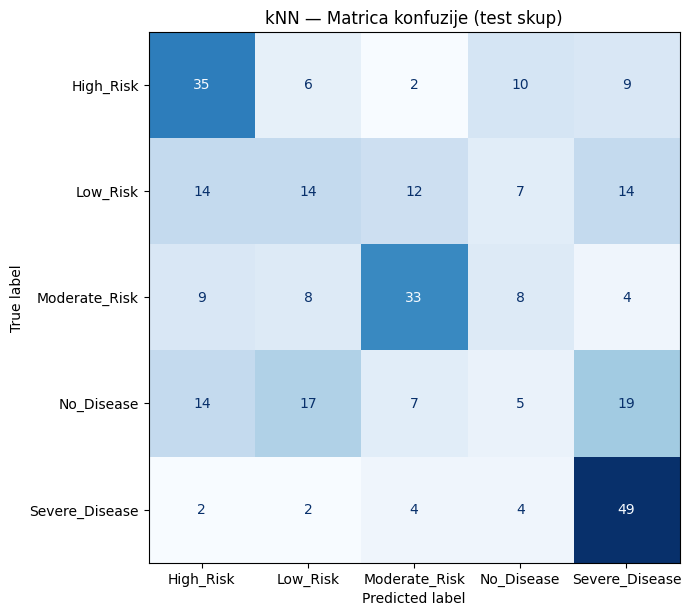

In [12]:
## knn klasifikator
## tok je sledeci : inicijalizacija (KNeighborsClassifier), obuka (fit) i primena obucenog modela (predict)

# -korak1- pipeline
knn_pipeline = Pipeline([
    ("preprocess", preprocess),
    ("knn", KNeighborsClassifier())
])

# -korak2- rečnik hiperparametara sadrži sve kombinaicje hiperparametara koje želim da isprobam
knn_param_grid = {
    "knn__n_neighbors": [3, 5, 7, 11, 15],
    "knn__metric":      ["euclidean", "manhattan", "mitkowski"],
    "knn__weights":     ["uniform", "distance"]
}

# -korak3- GridSearchCV
scorer = make_scorer(f1_score, average="macro")   
knn_grid_search = GridSearchCV(
    estimator  = knn_pipeline,
    param_grid = knn_param_grid,
    cv         = skf,                  #definisano u prethodnoj celiji
    scoring    = 'f1_macro',               #bira sta je najbolja komb
    n_jobs     = -1,                   #koristi sva procesorska jezgra
    verbose    = 1                     #ispisuje po 1 info tokom izvrsavanja
)

# -korak4- obuka
knn_grid_search.fit(X_trainval, y_trainval)
print("Najbolji hiperparametri:", knn_grid_search.best_params_)
print(f"Najbolji F1 (macro, CV): {knn_grid_search.best_score_:.4f}")

# -korak5- finalni model sa njaboljim parametrima
knn_best = knn_grid_search.best_estimator_

# -korak6- refit nad celim trainval skupom bi trebalo da se uradi automatski

# -korak7- primena obucenog modela
knn_y_pred = knn_best.predict(X_test)

# -korak8- evaluacija
print("\n")
print("=" * 55)
print("          kNN — Rezultati na test skupu")
print("=" * 55)
print("\n")

print(f"\nAccuracy:  {accuracy_score(y_test, knn_y_pred):.4f}")
print(f"F1 macro:  {f1_score(y_test, knn_y_pred, average='macro'):.4f}")

print("\nClassification report:")
print(classification_report(y_test, knn_y_pred))

# Matrica konfuzije
fig, ax = plt.subplots(figsize=(7, 9))
ConfusionMatrixDisplay.from_predictions(
    y_test, knn_y_pred,
    ax=ax,
    colorbar=False,
    cmap="Blues"
)
ax.set_title("kNN — Matrica konfuzije (test skup)")
plt.tight_layout()
plt.savefig('Prilozi/03_knn_matrica_konfuzije_test.png', dpi=150, bbox_inches='tight')
plt.show()

# Cuvanje rezultata za kasniju komparativnu analizu
results['kNN'] = {
    'f1_macro':  f1_score(y_test, knn_y_pred, average='macro'),
    'accuracy':  accuracy_score(y_test, knn_y_pred),
    'params':    knn_grid_search.best_params_
}

---
## 5. Random Forest klasifikator

Random Forest je ansambalni metod koji koristi skup stabala odluke. Ansambalsko učenje podrazumeva obuku više jednostavnih modela sa ciljem unapredenja performansi pri rešavanju kompleksnijih problema. Glavna ideja je da se obuči više stabala odluke, a krajnja odluka o klasi ili vrednosti nepoznatog uzorka dobija se glasanjem.

In [13]:
## random forest klasifikator

# -korak1- pipeline
rf_pipeline = Pipeline([
    ("preprocess", preprocess),
    ("rf", RandomForestClassifier(random_state=42,  class_weight='balanced'))
])

#TO-DO
# n_estimators dodaj jos 400
#bootstrap jos False
#max samples jos , 0.5, 0.8
#max dep jos 20
#min samples jos 5


# -korak2- rečnik hiperparametara                    
rf_params = {
        'rf__n_estimators' : [100, 200, 300, 400, 500],              #predstavlja broj stabala koji ce se obuciti, 
        'rf__bootstrap' : [True],                         #true -> koristi se deo podataka, false -> koristi se ceo skup podataka za obuku
        'rf__max_samples' : [0.3, 0.5],                   #govori koliko uzoraka se koristi pri obuci -> none koristi sve, 200 koristi 200 uzoraka, a 0.5 koristi 50% uzoraka
        'rf__max_depth': [10, 20, 30],                   #maksimalna dubina stabla -> ako je none idemo dok se listovi dalje ne mogu rastaviti (sadrze manje nego min_samples_split)
        'rf__min_samples_split': [2, 5],                   #minimalan broj uzoraka potreban za ratavljanje internog cvora
        'rf__max_features' : ['sqrt', 'log2']           #koliko obeležja se razmatra pri svakom splitu
}

# -korak3- GridSearchCV
rf_grid_search = GridSearchCV(
    estimator  = rf_pipeline,  
    param_grid = rf_params,
    cv         = skf,
    scoring    = 'f1_macro',
    n_jobs     = -1,
    verbose    = 1
)


# -korak4- obuka
rf_grid_search.fit(X_trainval, y_trainval)
print("Najbolji hiperparametri:", rf_grid_search.best_params_)
print("Najbolji F1 (macro, CV):", rf_grid_search.best_score_)


Fitting 5 folds for each of 120 candidates, totalling 600 fits
Najbolji hiperparametri: {'rf__bootstrap': True, 'rf__max_depth': 30, 'rf__max_features': 'sqrt', 'rf__max_samples': 0.5, 'rf__min_samples_split': 2, 'rf__n_estimators': 400}
Najbolji F1 (macro, CV): 0.4644135022441499




          Random Forest — Rezultati na test skupu



Accuracy:  0.4773
F1 macro:  0.4746

Classification report:
                precision    recall  f1-score   support

     High_Risk       0.45      0.55      0.49        62
      Low_Risk       0.27      0.23      0.25        61
 Moderate_Risk       0.60      0.60      0.60        62
    No_Disease       0.34      0.34      0.34        62
Severe_Disease       0.72      0.67      0.69        61

      accuracy                           0.48       308
     macro avg       0.48      0.48      0.47       308
  weighted avg       0.48      0.48      0.47       308



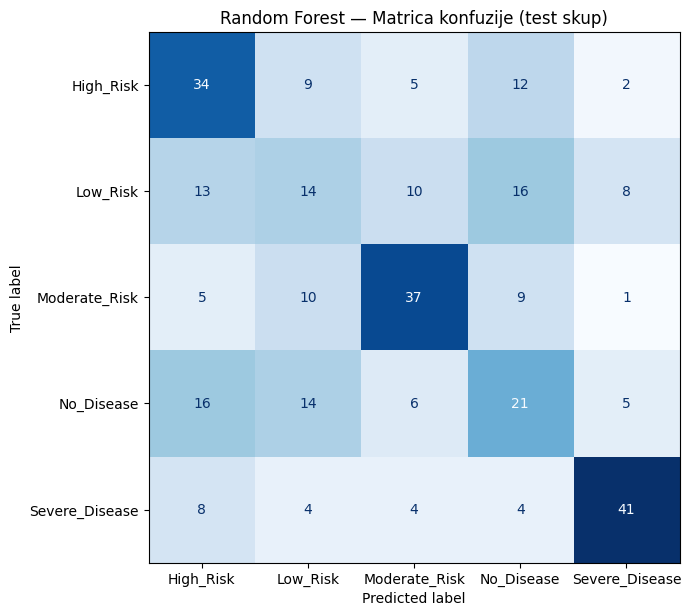

In [14]:
# -korak5- finalni model sa najboljim parametrima
rf_best = rf_grid_search.best_estimator_

# -korak6- primena obucenog modela
rf_y_pred = rf_best.predict(X_test)

# -korak7- evaluacija 
print("\n")
print("=" * 55)
print("          Random Forest — Rezultati na test skupu")
print("=" * 55)
print("\n")

print(f"\nAccuracy:  {accuracy_score(y_test, rf_y_pred):.4f}")
print(f"F1 macro:  {f1_score(y_test, rf_y_pred, average='macro'):.4f}")

print("\nClassification report:")
print(classification_report(y_test, rf_y_pred))

#Matrica konfuzije
fig, ax = plt.subplots(figsize=(7, 9))
ConfusionMatrixDisplay.from_predictions(
    y_test, rf_y_pred,
    ax=ax,
    colorbar = False,
    cmap = "Blues"
)
ax.set_title("Random Forest — Matrica konfuzije (test skup)")
plt.tight_layout()
plt.savefig('Prilozi/04_rf_matrica_konfuzije_test.png', dpi=150, bbox_inches='tight')
plt.show()

# Cuvanje rezultata za kasniju komparativnu analizu
results['Random Forest'] = {
    'f1_macro':  f1_score(y_test, rf_y_pred, average='macro'),
    'accuracy':  accuracy_score(y_test, rf_y_pred),
    'params':    rf_grid_search.best_params_
}


---
## 6. SVM Klasifikator

In [15]:
## svm klasifikator

scorer = make_scorer(f1_score, average="macro", zero_division=0)

# -korak1- pipeline
svm_pipeline = Pipeline([
    ("preprocess", preprocess),
    ("svm", SVC(decision_function_shape='ovr', class_weight='balanced', random_state=42)) 
])

svm_params = {
    "svm__C":       [0.001, 0.01, 0.1, 1, 10],  # Wider range for regularization
    "svm__kernel":  ["linear", "rbf", "poly"],           # RBF handles non-linearity better
    "svm__gamma":   ["scale", "auto"],                   # Start with 'scale'
    "svm__degree":  [2, 3],          # only used when kernel="poly"
}

# -korak3- GridSearchCV
svm_grid_search = GridSearchCV(
    estimator  = svm_pipeline,
    param_grid = svm_params,  
    cv         = skf,
    scoring    = 'f1_macro',
    n_jobs     = -1,
    verbose    = 1,
    error_score = 'raise'
)


# -korak4- obuka
svm_grid_search.fit(X_trainval, y_trainval)
print("Najbolji hiperparametri:", svm_grid_search.best_params_)
print("Najbolji F1 (macro, CV):", svm_grid_search.best_score_)

Fitting 5 folds for each of 60 candidates, totalling 300 fits
Najbolji hiperparametri: {'svm__C': 1, 'svm__degree': 3, 'svm__gamma': 'scale', 'svm__kernel': 'poly'}
Najbolji F1 (macro, CV): 0.4436332685037711




          SVM — Rezultati na test skupu



Accuracy:  0.4675
F1 macro:  0.4741

Classification report:
                precision    recall  f1-score   support

     High_Risk       0.52      0.53      0.53        62
      Low_Risk       0.30      0.28      0.29        61
 Moderate_Risk       0.58      0.55      0.56        62
    No_Disease       0.27      0.34      0.30        62
Severe_Disease       0.75      0.64      0.69        61

      accuracy                           0.47       308
     macro avg       0.48      0.47      0.47       308
  weighted avg       0.48      0.47      0.47       308



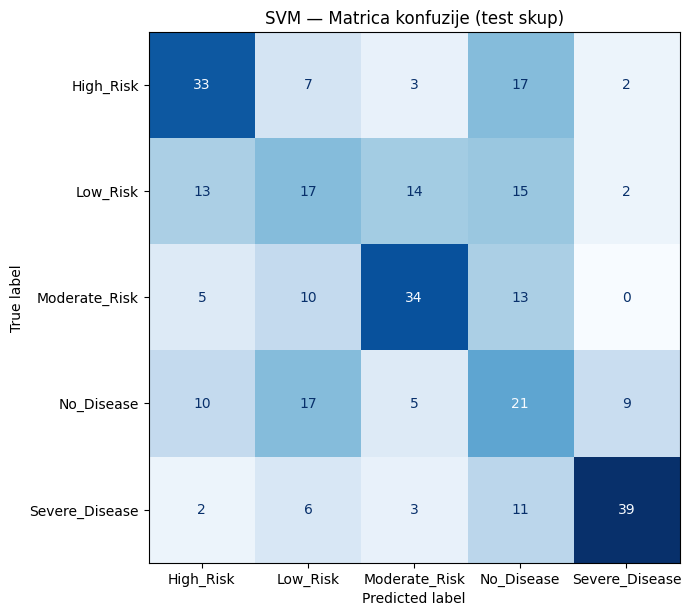

In [16]:
# -korak5- finalni model sa najboljim parametrima
svm_best = svm_grid_search.best_estimator_

# -korak6- primena obucenog modela
svm_y_pred = svm_best.predict(X_test)

# -korak7- evaluacija 
print("\n")
print("=" * 55)
print("          SVM — Rezultati na test skupu")
print("=" * 55)
print("\n")

print(f"\nAccuracy:  {accuracy_score(y_test, svm_y_pred):.4f}")
print(f"F1 macro:  {f1_score(y_test, svm_y_pred, average='macro'):.4f}")

print("\nClassification report:")
print(classification_report(y_test, svm_y_pred))

#Matrica konfuzije
fig, ax = plt.subplots(figsize=(7, 9))
ConfusionMatrixDisplay.from_predictions(
    y_test, svm_y_pred,
    ax=ax,
    colorbar = False,
    cmap = "Blues"
)
ax.set_title("SVM — Matrica konfuzije (test skup)")
plt.tight_layout()
plt.savefig('Prilozi/05_svm_matrica_konfuzije_test.png', dpi=150, bbox_inches='tight')
plt.show()

# Cuvanje rezultata za kasniju komparativnu analizu
results['SVM'] = {
    'f1_macro':  f1_score(y_test, svm_y_pred, average='macro'),
    'accuracy':  accuracy_score(y_test, svm_y_pred),
    'params':    svm_grid_search.best_params_
}

---
## 7. Redukcija dimenzionalnosti i ponovna klasifikacija

---
## 8. Komparativna analiza